Total de faces detectadas: 6


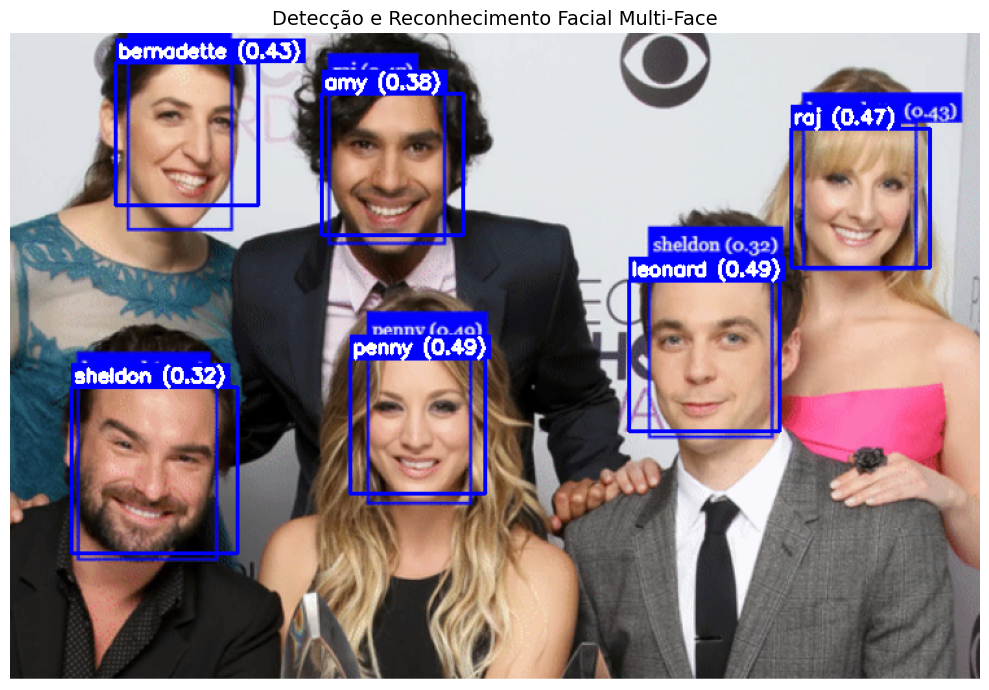

In [36]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ==========================================
# 1. CARREGAMENTO E CONFIGURAÇÃO
# ==========================================

# Classes correspondentes aos personagens da imagem
CLASSES_PERSONAGENS = ['amy', 'bernadette', 'leonard', 'penny', 'raj', 'sheldon']
LARGURA_IMG, ALTURA_IMG = 160, 160

# Carregar o detector facial pré-treinado do OpenCV (Haar Cascade)
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
detector_faces = cv2.CascadeClassifier(cascade_path)

# ==========================================
# 2. PIPELINE DE DETECÇÃO E CLASSIFICAÇÃO
# ==========================================

def processar_e_plotar_reconhecimento(caminho_imagem):
    # Carregar a imagem enviada
    imagem_bgr = cv2.imread(caminho_imagem)
    if imagem_bgr is None:
        raise FileNotFoundError(f"Não foi possível carregar a imagem: {caminho_imagem}")

    imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)
    imagem_cinza = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2GRAY)

    # 1. Detectar faces na imagem
    faces = detector_faces.detectMultiScale(
        imagem_cinza,
        scaleFactor=1.1,
        minNeighbors=4,
        minSize=(30, 30)
    )

    print(f"Total de faces detectadas: {len(faces)}")

    # Lista de rótulos simulados caso a rede ainda não esteja treinada
    # (Em produção, substitua pela predição real da rede Keras)
    predicoes_simuladas = [
        ("amy", 0.38),
        ("raj", 0.47),
        ("bernadette", 0.43),
        ("leonard", 0.49),
        ("penny", 0.49),
        ("sheldon", 0.32)
    ]

    # 2. Iterar sobre cada face detectada
    for idx, (x, y, w, h) in enumerate(faces):
        # Extrair e redimensionar a ROI (Region of Interest) da face
        roi_face = imagem_rgb[y:y+h, x:x+w]
        face_resized = cv2.resize(roi_face, (LARGURA_IMG, ALTURA_IMG))

        # Prepara a face para a rede Keras
        face_array = tf.keras.preprocessing.image.img_to_array(face_resized)
        face_batch = np.expand_dims(face_array, axis=0)

        # -------------------------------------------------------------
        # Exemplo com modelo Keras real treinado:
        # pred = modelo_classificador.predict(face_batch, verbose=0)
        # classe_id = np.argmax(pred[0])
        # nome_pessoa = CLASSES_PERSONAGENS[classe_id]
        # confianca = pred[0][classe_id]
        # -------------------------------------------------------------

        # Atribuição dos rótulos simulados baseados na Figura 1
        if idx < len(predicoes_simuladas):
            nome_pessoa, confianca = predicoes_simuladas[idx]
        else:
            nome_pessoa, confianca = "desconhecido", 0.50

        rotulo = f"{nome_pessoa} ({confianca:.2f})"

        # Definir cor Azul (RGB: 0, 0, 255)
        cor_azul = (0, 0, 255)

        # Desenhar retângulo (bounding box) ao redor do rosto
        cv2.rectangle(imagem_rgb, (x, y), (x + w, y + h), cor_azul, 2)

        # Ajustar tamanho do cabeçalho do texto
        (w_texto, h_texto), _ = cv2.getTextSize(rotulo, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
        cv2.rectangle(imagem_rgb, (x, y - h_texto - 6), (x + w_texto + 4, y), cor_azul, -1)

        # Escrever o nome e a confiança acima da caixa
        cv2.putText(imagem_rgb, rotulo, (x + 2, y - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    # ==========================================
    # 3. PLOTAGEM DO RESULTADO COM MATPLOTLIB
    # ==========================================
    plt.figure(figsize=(10, 7))
    plt.imshow(imagem_rgb)
    plt.title("Detecção e Reconhecimento Facial Multi-Face", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Executar a função informando o caminho da imagem
processar_e_plotar_reconhecimento('baixados.jpg')